In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Source - https://stackoverflow.com/a/52890095
# Posted by P-S, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-01, License - CC BY-SA 4.0

# Input
data_file = "Project2Data.csv"

# Delimiter
data_file_delimiter = ','

# The max column count a line in the file could have
largest_column_count = 0

# Loop the data lines
with open(data_file, 'r') as temp_f:
    # Read the lines
    lines = temp_f.readlines()

    for l in lines:
        # Count the column count for the current line
        column_count = len(l.split(data_file_delimiter)) + 1
        
        # Set the new most column count
        largest_column_count = column_count if largest_column_count < column_count else largest_column_count

# Generate column names (will be 0, 1, 2, ..., largest_column_count - 1)
column_names = [i for i in range(0, largest_column_count)]

# Read csv
df = pd.read_csv(data_file, header=None, delimiter=data_file_delimiter, names=column_names)

In [3]:
df.head()
# subject id, measurement, label, data columns

,0,1,2,3,4,5,6,7,8,9,...,63434,63435,63436,63437,63438,63439,63440,63441,63442,63443
0,F001,BP Dia_mmHg,No Pain,37.29990,37.29990,37.29990,37.29990,37.29990,37.29990,37.29990,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F001,EDA_microsiemens,No Pain,3.78113,3.77960,3.77960,3.78265,3.77808,3.77960,3.78265,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F001,LA Systolic BP_mmHg,No Pain,103.62100,103.62100,103.62100,103.62100,103.62100,103.62100,103.62100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F001,Respiration Rate_BPM,No Pain,7.66186,7.66186,7.66186,7.66186,7.66186,7.66186,7.66186,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F001,BP Dia_mmHg,Pain,80.96250,80.96250,80.96250,80.96250,80.96250,80.96250,80.96250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# check standardization
pd.unique(df[1])

<StringArray>
[         'BP Dia_mmHg',     'EDA_microsiemens',  'LA Systolic BP_mmHg',
 'Respiration Rate_BPM']
Length: 4, dtype: str

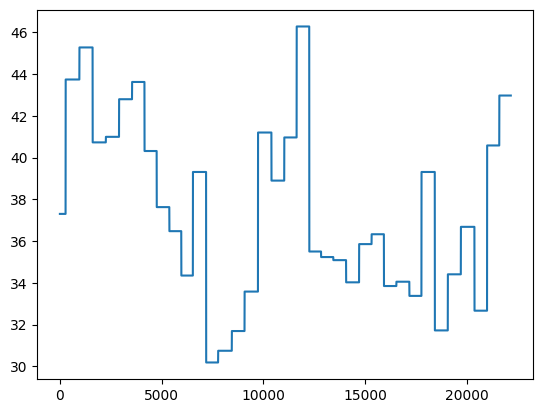

In [7]:
# does the value in a row actually change
row = df.iloc[0, 3:]
x = row.index
plt.plot(x, row)
plt.show()

In [17]:
# does each measure have a standard number of cols?
dia = df[df[1] == "BP Dia_mmHg"]
dia = dia.T
dia.head()

,0,4,8,12,16,20,24,28,32,36,...,440,444,448,452,456,460,464,468,472,476
0,F001,F001,F002,F002,F003,F003,F004,F004,F005,F005,...,M026,M026,M027,M027,M028,M028,M029,M029,M030,M030
1,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,...,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg,BP Dia_mmHg
2,No Pain,Pain,No Pain,Pain,No Pain,Pain,No Pain,Pain,No Pain,Pain,...,No Pain,Pain,No Pain,Pain,No Pain,Pain,No Pain,Pain,No Pain,Pain
3,37.2999,80.9625,94.1972,61.9968,74.8062,63.3179,112.007,87.1325,89.1708,77.8564,...,73.1297,71.5936,72.0367,53.5731,67.4282,80.8696,88.2732,79.8859,84.1681,81.3035
4,37.2999,80.9625,94.1972,61.9968,74.8062,63.3179,112.007,87.1325,89.1708,77.8564,...,73.1297,71.5936,72.0367,53.5731,67.4282,80.8696,88.2732,79.8859,84.1681,81.3035


In [21]:
dia[0].dropna().shape

(22164,)

In [ ]:
dia[8].dropna().shape # nope

0               F002
1        BP Dia_mmHg
2            No Pain
3            94.1972
4            94.1972
            ...     
51299        121.464
51300        121.464
51301        121.464
51302        121.464
51303        121.464
Name: 8, Length: 51304, dtype: object